# Cluster Performance Data Exploratory Analysis

This notebook provides exploratory data analysis for the cluster performance dataset.

In [10]:
import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_preprocessor import ClusterDataPreprocessor

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

%matplotlib inline

## Load and Explore Data

In [11]:
# Load data
preprocessor = ClusterDataPreprocessor('../configs/config.yaml')
df = preprocessor.load_data('../data/raw/cluster_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
df.head(10)

INFO:src.data_preprocessor:Loading data from ../data/raw/cluster_data.csv
INFO:src.data_preprocessor:Data loaded successfully. Shape: (6858, 51)


Dataset shape: (6858, 51)
Columns: 51


,clusterType,cluster_health_score,controlPlaneArch,cpu-kube-apiserver,cpu-masters,cpu-workers,infraNodeMemory,infraNodesCount,infraNodesType,infraNodevCPU,...,podLatencyQuantilesMeasurement_Ready_P99,publish,region,sdnType,totalNodes,workerArch,workerNodeMemory,workerNodesCount,workerNodesType,workerNodevCPU
0,self-managed,Yellow,NaN,0.133924,0.570089,0.743870,32.0,3.0,r5.xlarge,4.0,...,13000,NaN,us-west-2,OVNKubernetes,12,NaN,16.0,6,m6a.xlarge,4.0
1,self-managed,Yellow,NaN,0.129503,0.552771,0.699396,32.0,3.0,r5.xlarge,4.0,...,13000,NaN,us-west-2,OVNKubernetes,12,NaN,16.0,6,m6a.xlarge,4.0
2,self-managed,Yellow,NaN,0.355151,1.169458,0.511236,NaN,NaN,NaN,NaN,...,13000,NaN,us-west-2,OVNKubernetes,27,NaN,16.0,24,m6a.xlarge,4.0
3,self-managed,Yellow,NaN,0.126916,0.538846,0.683194,32.0,3.0,r5.xlarge,4.0,...,13000,NaN,us-west-2,OVNKubernetes,12,NaN,16.0,6,m6a.xlarge,4.0
4,self-managed,Yellow,NaN,0.094041,0.646889,0.695481,NaN,NaN,NaN,NaN,...,19000,NaN,us-west-2,OVNKubernetes,3,NaN,NaN,3,NaN,NaN
5,self-managed,Yellow,NaN,0.074826,0.622759,0.627074,NaN,NaN,NaN,NaN,...,18000,NaN,us-west-2,OVNKubernetes,3,NaN,NaN,3,NaN,NaN
6,self-managed,Yellow,NaN,0.127537,0.557492,0.721908,32.0,3.0,r5.xlarge,4.0,...,13000,NaN,us-west-2,OVNKubernetes,12,NaN,16.0,6,m6a.xlarge,4.0
7,self-managed,Yellow,NaN,0.128828,0.556083,0.684322,32.0,3.0,r5.xlarge,4.0,...,13000,NaN,us-west-2,OVNKubernetes,12,NaN,16.0,6,m6a.xlarge,4.0
8,rosa,Yellow,NaN,0.533041,2.077322,0.516730,32.0,3.0,r5.xlarge,4.0,...,14000,NaN,us-west-2,OVNKubernetes,30,NaN,16.0,24,m5.xlarge,4.0
9,rosa,Yellow,NaN,0.560274,2.184138,0.491763,32.0,3.0,r5.xlarge,4.0,...,13000,NaN,us-west-2,OVNKubernetes,30,NaN,16.0,24,m5.xlarge,4.0


## Data Quality Analysis

In [13]:
# Missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
missing_df

Columns with missing values: 18


,Missing Count,Missing Percentage
jobConfig.metricsClosing,5734,83.610382
ipsecMode,1032,15.048119
workerArch,1032,15.048119
publish,1032,15.048119
controlPlaneArch,1032,15.048119
infraNodesCount,487,7.101196
infraNodesType,487,7.101196
infraNodevCPU,487,7.101196
infraNodeMemory,487,7.101196
workerNodeMemory,151,2.201808


## Feature and Target Identification

In [14]:
# Identify feature and target columns
feature_cols, target_cols = preprocessor.identify_columns(df)

print(f"Feature columns: {len(feature_cols)}")
print(f"Target columns: {len(target_cols)}")

print("\nFeature columns:")
for col in feature_cols:
    print(f"  - {col}")

print("\nTarget columns:")
for col in target_cols:
    print(f"  - {col}")

INFO:src.data_preprocessor:Identifying feature and target columns...
INFO:src.data_preprocessor:Identified 45 feature columns
INFO:src.data_preprocessor:Identified 6 target columns


Feature columns: 45
Target columns: 6

Feature columns:
  - clusterType
  - cluster_health_score
  - controlPlaneArch
  - infraNodeMemory
  - infraNodesCount
  - infraNodesType
  - infraNodevCPU
  - ipsecMode
  - jobConfig.burst
  - jobConfig.churnDelay
  - jobConfig.churnDeletionStrategy
  - jobConfig.churnDuration
  - jobConfig.churnPercent
  - jobConfig.cleanup
  - jobConfig.iterationsPerNamespace
  - jobConfig.jobIterations
  - jobConfig.jobType
  - jobConfig.maxWaitTimeout
  - jobConfig.metricsClosing
  - jobConfig.name
  - jobConfig.preLoadPeriod
  - jobConfig.qps
  - jobConfig.verifyObjects
  - jobConfig.waitForDeletion
  - jobConfig.waitWhenFinished
  - k8sVersion
  - masterNodeMemory
  - masterNodesCount
  - masterNodesType
  - masterNodevCPU
  - metricName
  - ocpMajorVersion
  - ocpVersion
  - passed
  - platform
  - podLatencyQuantilesMeasurement_Ready_P99
  - publish
  - region
  - sdnType
  - totalNodes
  - workerArch
  - workerNodeMemory
  - workerNodesCount
  - workerNo

## Feature Analysis

Categorical features: 19


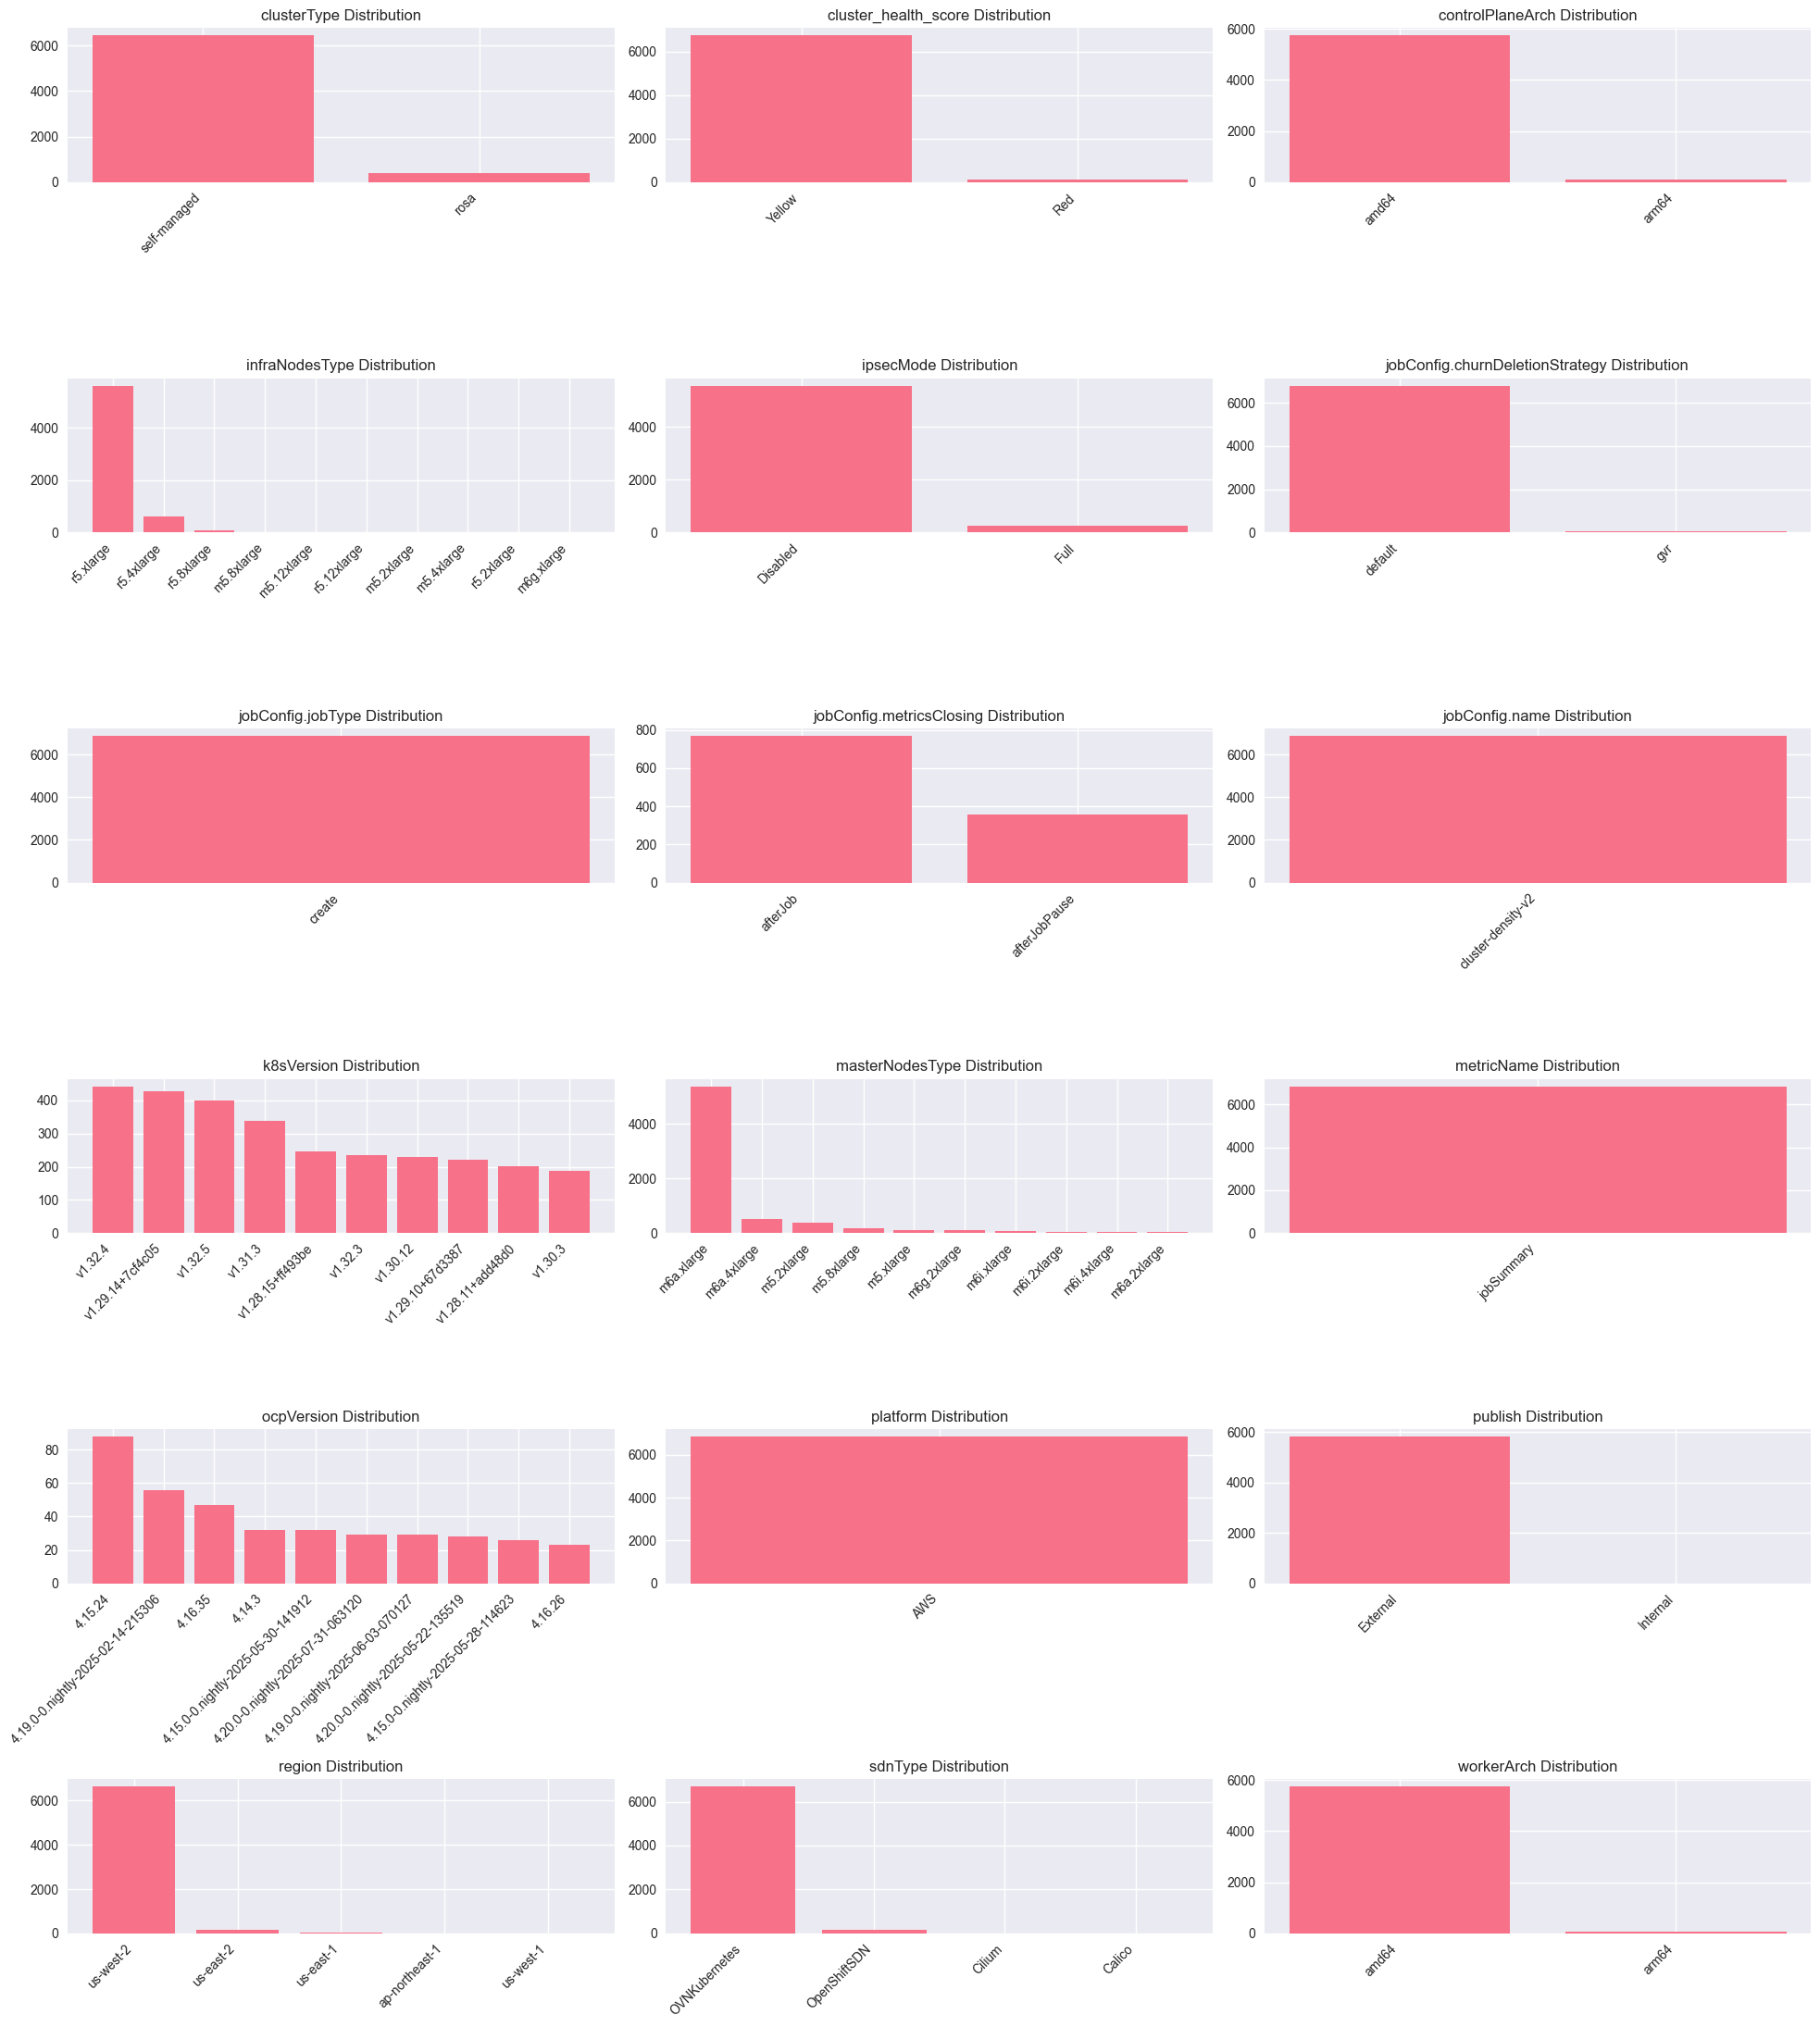

In [33]:
# Analyze categorical features
categorical_features = df[feature_cols].select_dtypes(include=['object']).columns

print(f"Categorical features: {len(categorical_features)}")

fig, axes = plt.subplots(6, 3, figsize=(20, 22))
axes = axes.ravel()

for i, col in enumerate(categorical_features[:18]):
    value_counts = df[col].value_counts().head(10)
    axes[i].bar(range(len(value_counts)), value_counts.values)
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Target Metrics Analysis

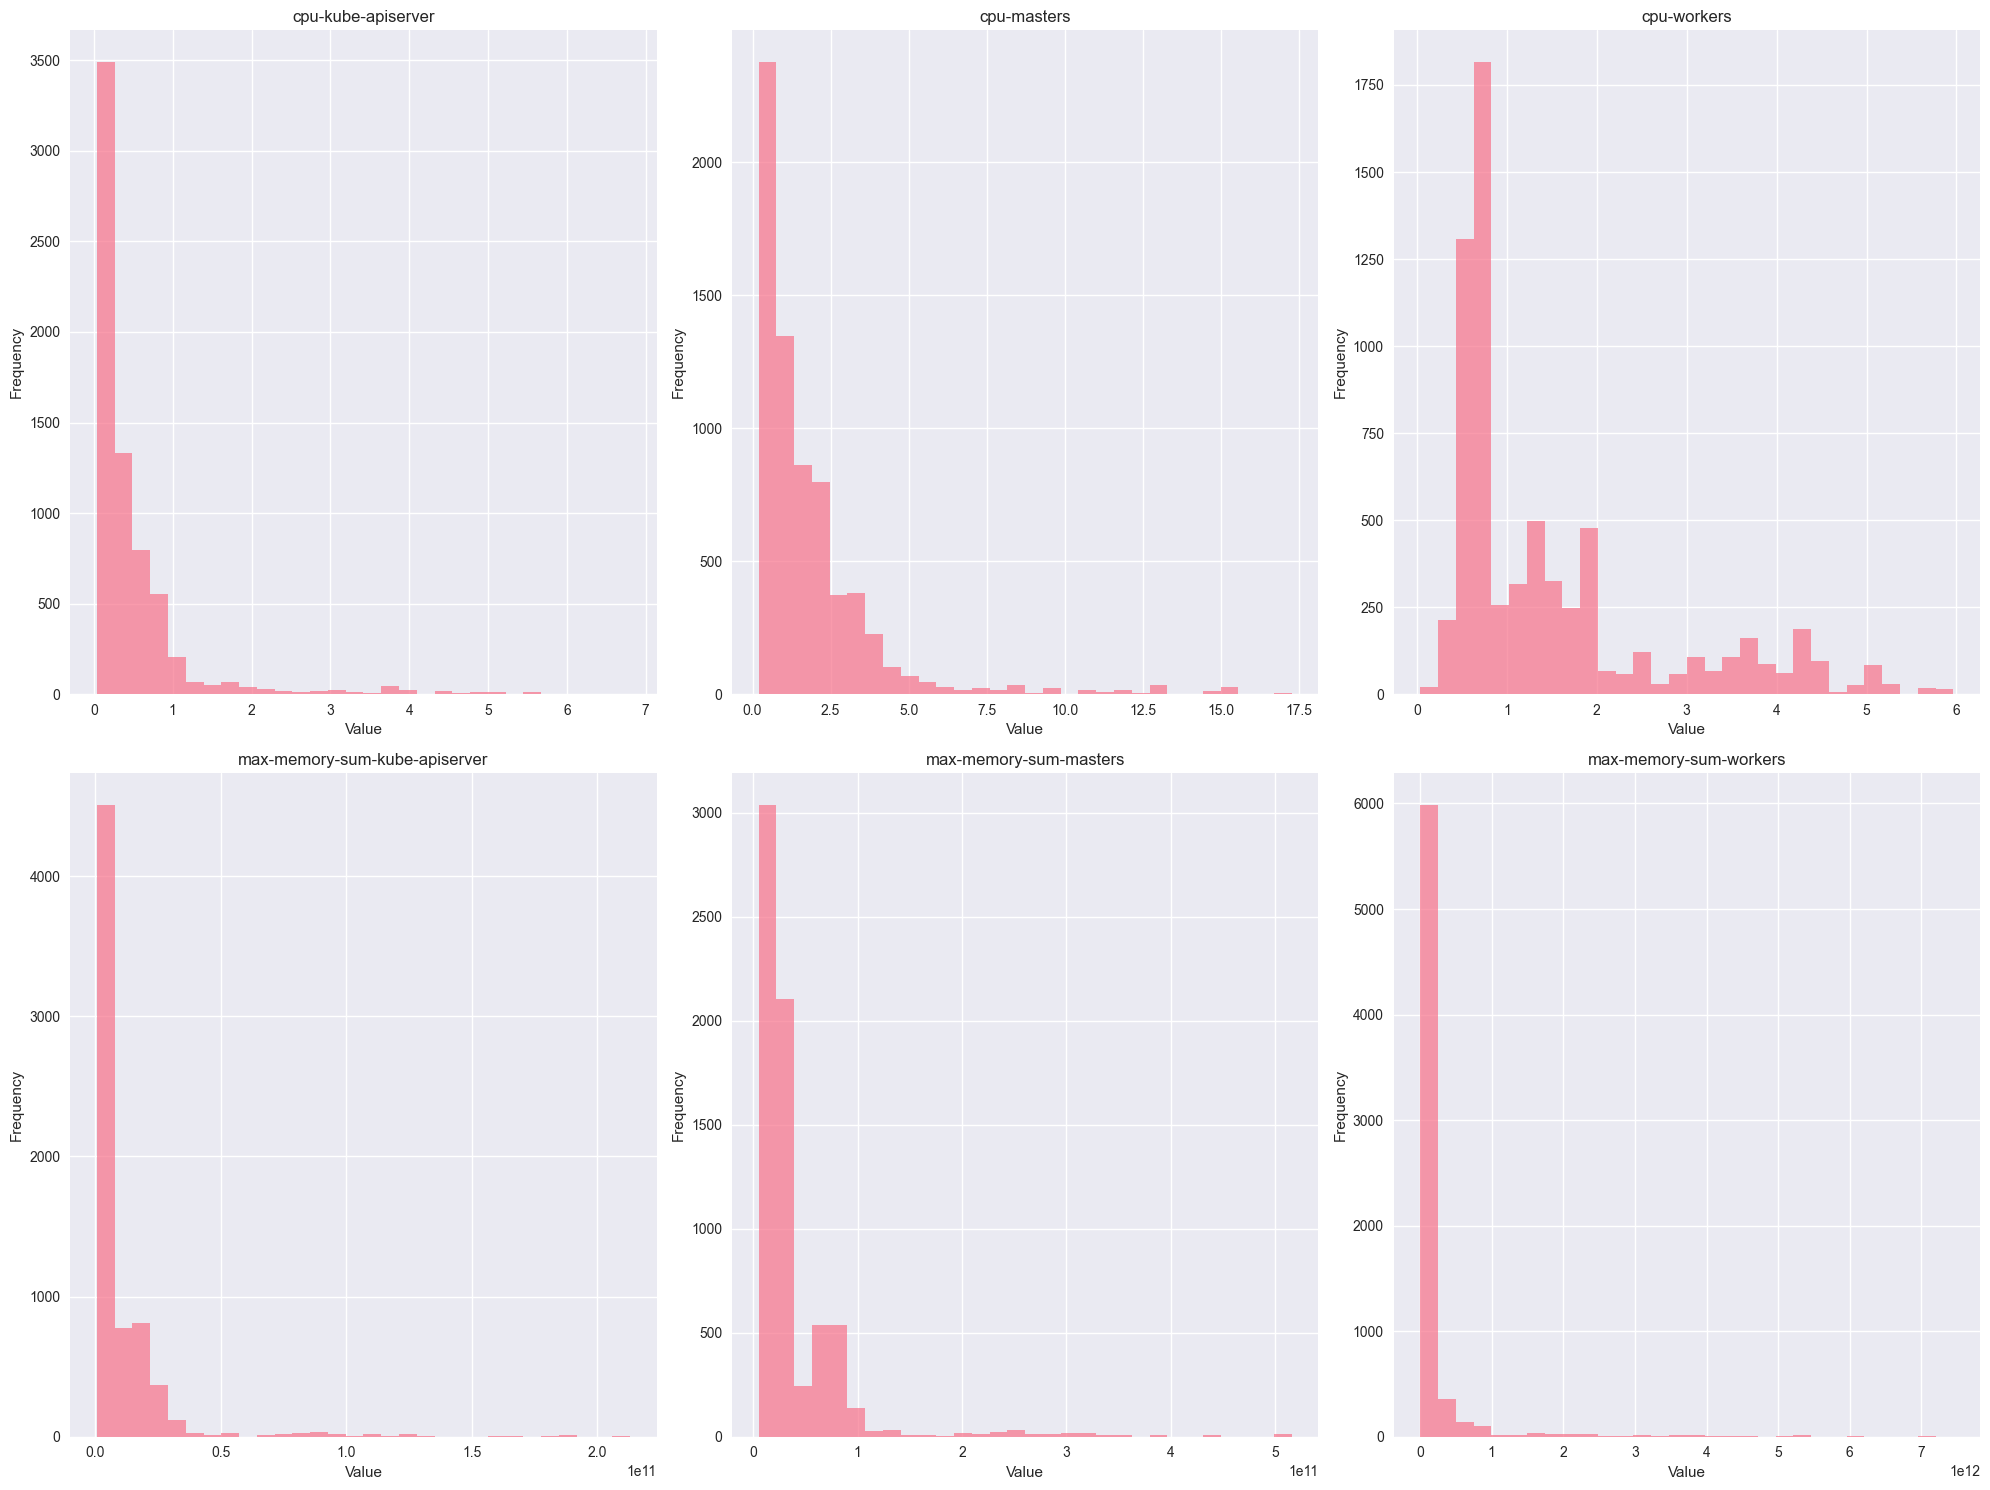

In [27]:
# Analyze target distributions
numerical_targets = df[target_cols].select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_targets):
    df[col].hist(bins=30, ax=axes[i], alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Correlation Analysis

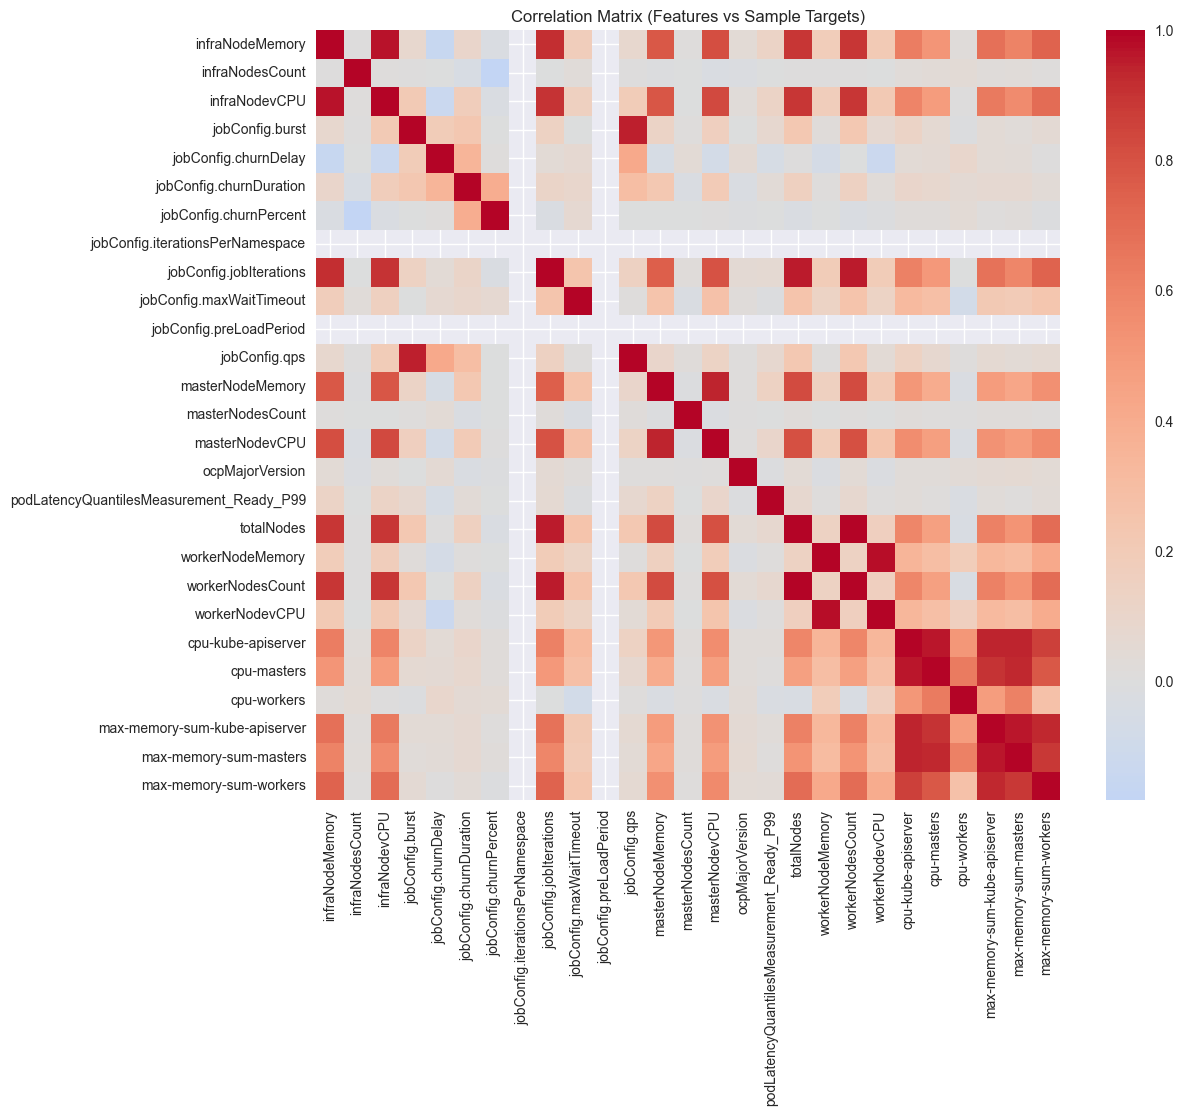

In [28]:
# Correlation between numerical features and targets
numerical_features = df[feature_cols].select_dtypes(include=[np.number]).columns
sample_targets = df[target_cols].select_dtypes(include=[np.number]).columns

if len(numerical_features) > 0 and len(sample_targets) > 0:
    corr_data = df[list(numerical_features) + list(sample_targets)]
    correlation_matrix = corr_data.corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix (Features vs Sample Targets)')
    plt.show()
else:
    print("No numerical features or targets found for correlation analysis")

## Summary Statistics

In [34]:
pd.set_option('display.max_columns', None)  # show all columns

# Summary statistics for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
summary_stats = df[numerical_cols].describe()

print("Summary statistics for numerical columns:")
summary_stats.round(4)

Summary statistics for numerical columns:


,cpu-kube-apiserver,cpu-masters,cpu-workers,infraNodeMemory,infraNodesCount,infraNodevCPU,jobConfig.burst,jobConfig.churnDelay,jobConfig.churnDuration,jobConfig.churnPercent,jobConfig.iterationsPerNamespace,jobConfig.jobIterations,jobConfig.maxWaitTimeout,jobConfig.preLoadPeriod,jobConfig.qps,masterNodeMemory,masterNodesCount,masterNodevCPU,max-memory-sum-kube-apiserver,max-memory-sum-masters,max-memory-sum-workers,ocpMajorVersion,podLatencyQuantilesMeasurement_Ready_P99,totalNodes,workerNodeMemory,workerNodesCount,workerNodevCPU
count,6854.0000,6855.0000,6855.0000,6371.0000,6371.0000,6371.0000,6858.0000,6.858000e+03,6.858000e+03,6858.0000,6858.0,6858.0000,6.858000e+03,6.858000e+03,6858.0000,6858.0000,6858.0000,6858.0000,6.855000e+03,6.855000e+03,6.855000e+03,6858.0000,6.858000e+03,6858.0000,6707.0000,6858.0000,6707.0000
mean,0.5015,1.8750,1.4927,45.2626,2.9925,5.7567,20.0685,1.173607e+11,1.240131e+12,10.1473,1.0,265.7855,1.522310e+13,1.500000e+10,19.8666,26.0414,2.9972,6.3074,1.206451e+10,3.838178e+10,1.950887e+11,4.1715,1.703828e+04,34.7877,19.3875,29.0516,4.5201
std,0.7184,2.1469,1.2366,40.1129,0.0935,5.4283,9.7864,1.604772e+10,4.927007e+11,2.2850,0.0,493.3330,1.649455e+12,0.000000e+00,4.3818,33.4337,0.0827,6.4069,2.033330e+10,5.136317e+10,6.609642e+11,0.0531,1.270532e+05,66.0779,36.0306,65.9689,4.7116
min,0.0379,0.1951,0.0369,16.0000,1.0000,4.0000,5.0000,5.000000e+09,6.000000e+10,10.0000,1.0,1.0000,3.600000e+12,1.500000e+10,5.0000,16.0000,1.0000,4.0000,7.160955e+08,5.249200e+09,2.157001e+09,0.0000,7.000000e+03,1.0000,8.0000,1.0000,2.0000
25%,0.1275,0.5669,0.6381,32.0000,3.0000,4.0000,20.0000,1.200000e+11,1.200000e+12,10.0000,1.0,90.0000,1.440000e+13,1.500000e+10,20.0000,16.0000,3.0000,4.0000,3.261397e+09,1.245403e+10,1.467827e+10,4.1600,1.100000e+04,12.0000,16.0000,6.0000,4.0000
50%,0.2544,1.1135,0.8673,32.0000,3.0000,4.0000,20.0000,1.200000e+11,1.200000e+12,10.0000,1.0,90.0000,1.440000e+13,1.500000e+10,20.0000,16.0000,3.0000,4.0000,6.131712e+09,2.326921e+10,2.920891e+10,4.1700,1.300000e+04,12.0000,16.0000,6.0000,4.0000
75%,0.5616,2.1764,1.8585,32.0000,3.0000,4.0000,20.0000,1.200000e+11,1.200000e+12,10.0000,1.0,216.0000,1.440000e+13,1.500000e+10,20.0000,16.0000,3.0000,4.0000,1.381451e+10,3.909791e+10,8.736745e+10,4.1900,1.400000e+04,30.0000,16.0000,24.0000,4.0000
max,6.8014,17.2588,5.9657,384.0000,3.0000,72.0000,300.0000,1.200000e+11,5.400000e+12,90.0000,1.0,4500.0000,2.880000e+13,1.500000e+10,150.0000,512.0000,4.0000,72.0000,2.130643e+11,5.156352e+11,7.446055e+12,4.2000,9.771000e+06,756.0000,512.0000,750.0000,72.0000


## Data Preprocessing Preview

In [30]:
# Preview preprocessing steps
print("Preprocessing pipeline preview...")

# Clean data
df_clean = preprocessor.clean_data(df)
print(f"After cleaning - Missing values: {df_clean.isnull().sum().sum()}")

# Encode categorical features
df_encoded = preprocessor.encode_categorical_features(df_clean, fit=True)
print(f"After encoding - Categorical columns: {len(df_encoded.select_dtypes(include=['object']).columns)}")

# Preview feature and target separation
X = df_encoded[feature_cols].copy()
y = df_encoded[target_cols].copy()

print(f"\nFeatures shape: {X.shape}")
print(f"Targets shape: {y.shape}")

print("\nPreprocessing completed successfully!")

INFO:src.data_preprocessor:Cleaning data...
INFO:src.data_preprocessor:Missing values before cleaning: 12282
INFO:src.data_preprocessor:Missing values after cleaning: 0
INFO:src.data_preprocessor:Encoding categorical features...


Preprocessing pipeline preview...
After cleaning - Missing values: 0
After encoding - Categorical columns: 0

Features shape: (6858, 45)
Targets shape: (6858, 6)

Preprocessing completed successfully!
